In [1]:
setClass("SnakemakeStub", representation(input = "list", params = "list"))
snakemake <- new("SnakemakeStub",
    input = list(saturation_long = "/home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/02_archs4/01_saturation/saturation_long.csv"),
    params = list(saturation_dir = "output/03_model_biology/02_archs4/01_saturation",
                  ora_root = "output/01_model_building/02_archs4/03_saturation_study/ora"))


# ARCHS4 saturation: pathway recovery against model rank K

Coverage asks how much *data* CLAMP needs; this asks how much *model capacity*, and whether the two interact. Subsampling is by study, the same draws coverage uses, so K is the only thing varying within a fraction. Recovery uses FDR 0.01 throughout, recomputed here from each ORA's saved per-LV results.

💡 **Environment:** `clamp-analyses`

## Libraries

In [2]:
suppressPackageStartupMessages({
    library(data.table)
    library(ggplot2)
    library(ggrepel)
    library(here)
})

SATURATION_DIR <- here(snakemake@params[["saturation_dir"]])
ORA_ROOT <- here(snakemake@params[["ora_root"]])
stopifnot(nrow(fread(snakemake@input[["saturation_long"]])) > 0)

FDR <- 0.05

# Recovery is recomputed from each ORA's saved per-LV results rather than read
# from the summary column, so FDR above is the single knob controlling every
# number and figure below.  At 0.05 it reproduces the pipeline's own counts
# (workflow/config/archs4.yaml sets the same cutoff); a stricter value would
# still work without rerunning enricher, because BH-adjusted p-values only grow
# under adjustment and everything eligible was written out at pvalueCutoff 0.05.
#
# NOTE: summary.csv carries its own `fdr` column.  Inside a data.table
# expression a column of that name would shadow a variable called `fdr`, which
# is why the cutoff is the uppercase FDR.
summary_paths <- list.files(ORA_ROOT, pattern = "^summary\\.csv$", recursive = TRUE, full.names = TRUE)
canonical <- "/rs[0-9]+/k[0-9]+/seed[0-9]+/[^./]+/[^./]+/summary\\.csv$"
summary_paths <- grep(canonical, summary_paths, value = TRUE)

saturation <- rbindlist(lapply(summary_paths, function(path) {
    s <- fread(path)
    parts <- strsplit(path, "/", fixed = TRUE)[[1]]
    # .../rs{f}/k{K}/seed{s}/{model}/{database}/summary.csv
    #        -5    -4     -3      -2         -1            0
    k_part <- parts[length(parts) - 4L]
    stopifnot(grepl("^k[0-9]+$", k_part))
    s[, k := as.integer(sub("^k", "", k_part))]
    enrich <- fread(file.path(dirname(path), "enrichment.csv.gz"), select = c("ID", "p.adjust"))
    recovered <- if (nrow(enrich)) uniqueN(enrich[`p.adjust` < FDR, ID]) else 0L
    s[, `:=`(
        recovered_pathways = recovered,
        recovered_percent = 100 * recovered / eligible_pathways,
        fdr = FDR
    )]
    s
}), fill = TRUE)

# The rank a model carries must match the rank its path claims.
stopifnot(saturation[, all(latent_variables == k)])

model_colors <- c(CLAMPfull = "#0072B2", CLAMPbase = "#777777")
saturation[, model := factor(model, levels = c("CLAMPfull", "CLAMPbase"))]
saturation[, .N, by = .(model, database)]

model,database,N
<fct>,<chr>,<int>
CLAMPbase,canonical,107
CLAMPbase,cellmarker,107
CLAMPbase,reactome,107
CLAMPfull,canonical,35
CLAMPfull,cellmarker,35
CLAMPfull,reactome,35


## Grid coverage

What actually finished, so a partial campaign still renders.

In [3]:
saturation[, .(cells = uniqueN(paste(fraction, k, seed)), databases = uniqueN(database)),
           by = .(model)][order(model)]

model,cells,databases
<fct>,<int>,<int>
CLAMPfull,35,3
CLAMPbase,107,3


## Recovery against K, one series per subsampling level

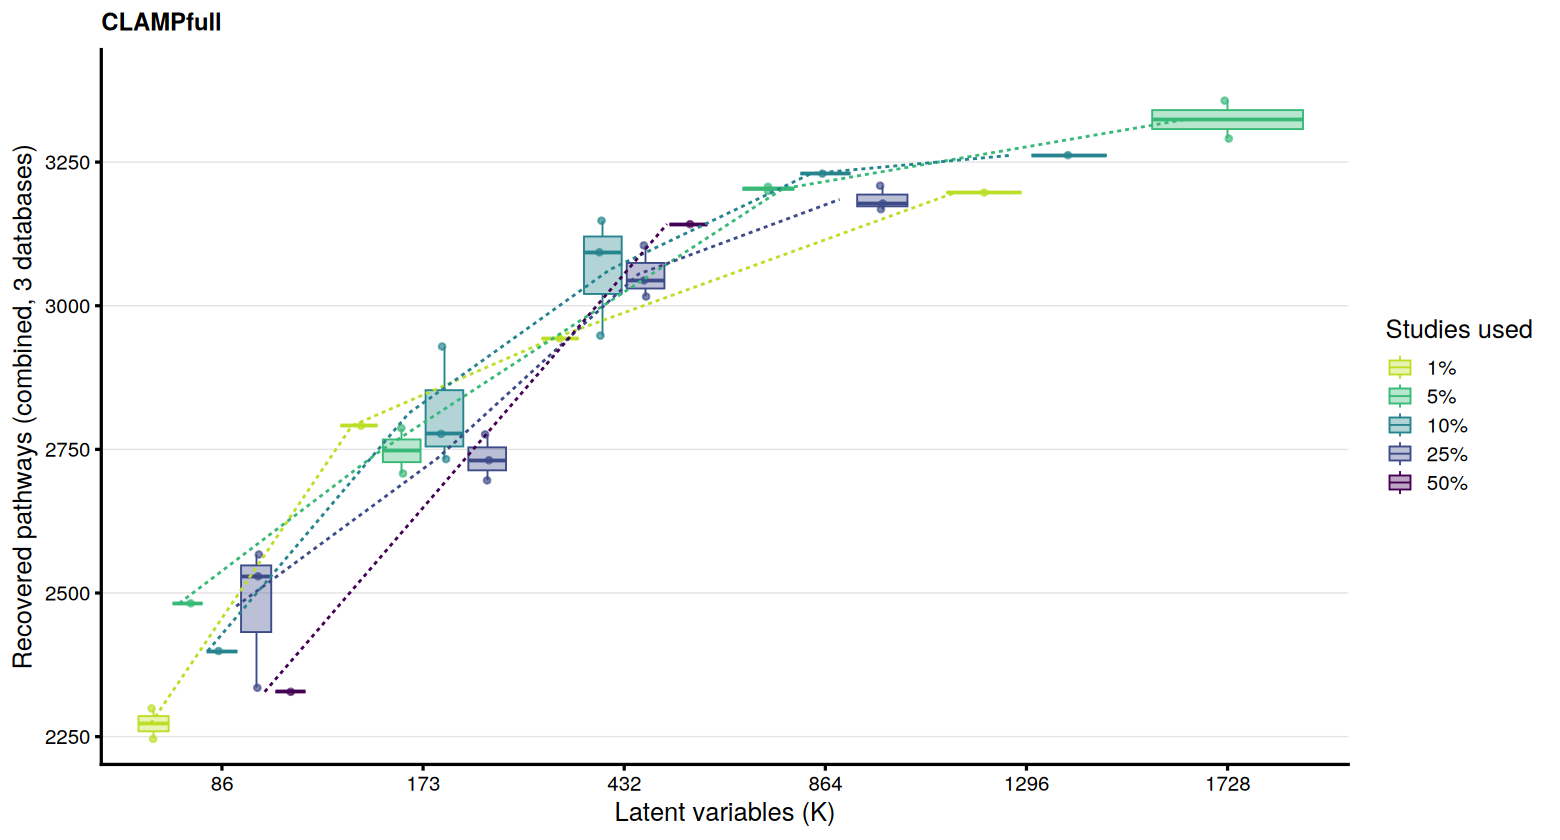

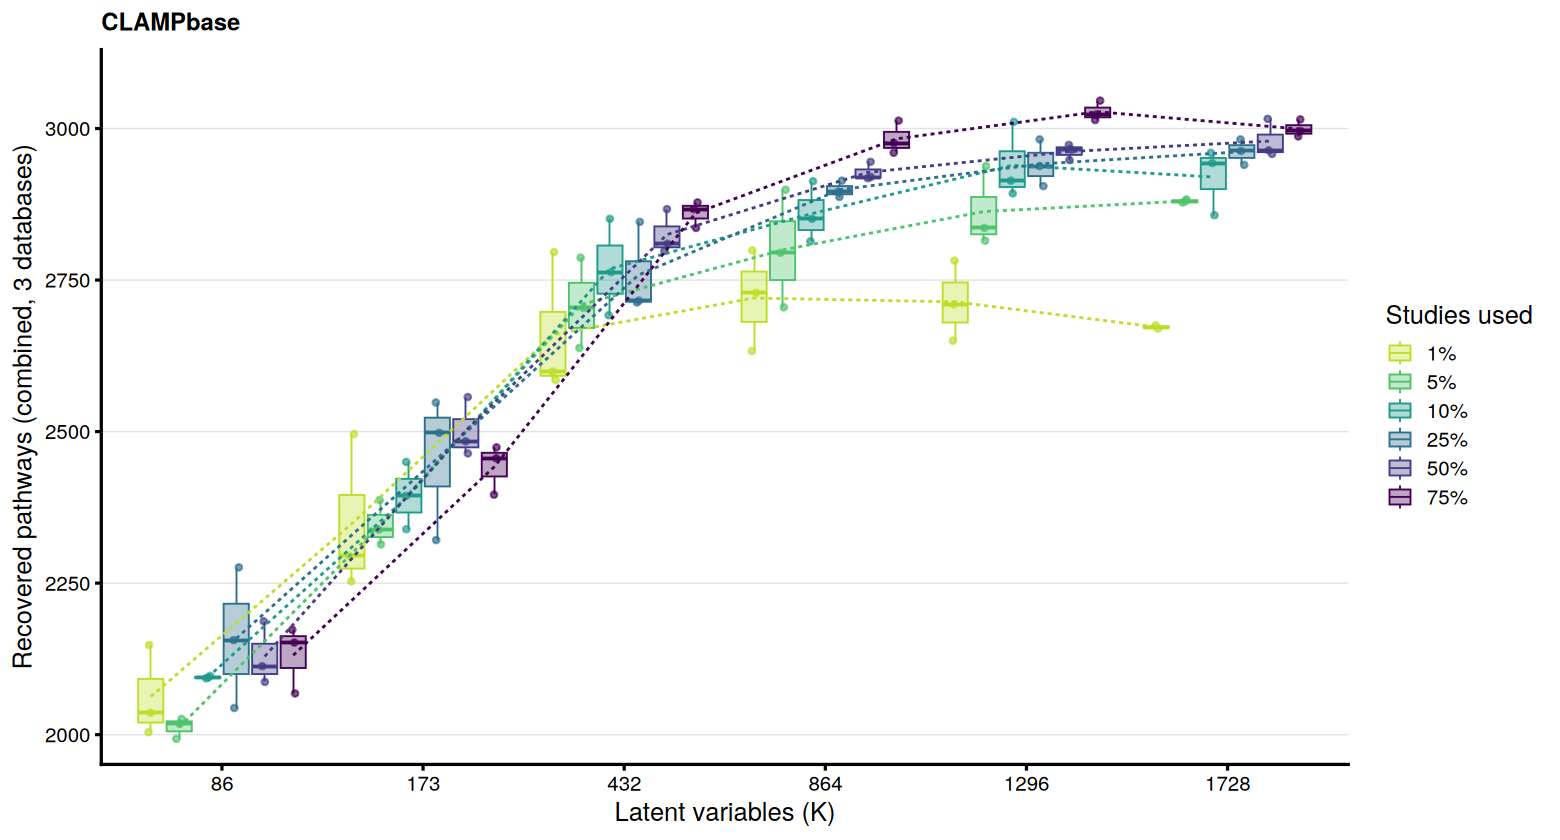

In [4]:
# Databases are combined: the three collections are scored independently but
# their counts are summed for display, exactly as in the coverage report.
sat_seed <- saturation[, .(
    recovered_pathways = sum(recovered_pathways),
    eligible_pathways = sum(eligible_pathways)
), by = .(fraction, k, seed, model)]
sat_seed[, k_label := factor(k, levels = sort(unique(k)))]
sat_seed[, fraction_label := factor(sprintf("%d%%", fraction),
                                     levels = sprintf("%d%%", sort(unique(fraction))))]

DODGE <- position_dodge(width = 0.85)
# Where position_dodge puts each group's box within a K slot, so the mean
# trajectory can be drawn on the same x positions instead of re-dodging.
dodge_offset <- function(g) {
    n <- nlevels(g)
    (as.integer(g) - (n + 1) / 2) * (0.85 / n)
}

# All fractions share one panel, dodged side by side at each K, so the curves
# can be read against each other directly.  Boxes span the three seeds.
make_k_plot <- function(model_name) {
    d <- sat_seed[model == model_name]
    if (!nrow(d)) return(invisible(NULL))
    means <- d[, .(recovered_pathways = mean(recovered_pathways)),
               by = .(fraction_label, k_label)]
    means[, x := as.integer(k_label) + dodge_offset(fraction_label)]
    ggplot(d, aes(k_label, recovered_pathways, fill = fraction_label, colour = fraction_label)) +
        geom_boxplot(position = DODGE, width = 0.75, outlier.shape = NA,
                     alpha = 0.35, linewidth = 0.4) +
        geom_point(position = position_jitterdodge(jitter.width = 0.12, dodge.width = 0.85),
                   size = 1.1, alpha = 0.65, show.legend = FALSE) +
        geom_line(data = means, aes(x = x, group = fraction_label),
                  linetype = "dashed", linewidth = 0.6, show.legend = FALSE) +
        scale_fill_viridis_d(end = 0.9, direction = -1) +
        scale_colour_viridis_d(end = 0.9, direction = -1) +
        scale_y_continuous(expand = expansion(mult = c(0.04, 0.08))) +
        labs(x = "Latent variables (K)",
             y = "Recovered pathways (combined, 3 databases)",
             fill = "Studies used", colour = "Studies used",
             title = model_name) +
        theme_classic(base_size = 15) +
        theme(panel.grid.major.y = element_line(colour = "#E3E3E3", linewidth = 0.3),
              plot.title = element_text(face = "bold", size = 14),
              legend.position = "right")
}

options(repr.plot.width = 13, repr.plot.height = 7)
make_k_plot("CLAMPfull")
make_k_plot("CLAMPbase")


## The full compendium against each smaller one, at the largest K

At the largest rank the model is no longer the bottleneck, so this asks whether
using all the studies recovers more pathways than using fewer. Every subsampling
level is tested against the 75% reference with a one-sided Student's t-test
(pooled variance), BH-adjusted across the five comparisons. The test is
one-sided because the question is directional. With three seeds per group the
result is sensitive to that choice: a Welch test on the same data leaves every
comparison non-significant two-sided, so read the effect sizes alongside the
stars.


CLAMPfull: not enough cells at K=1728 to compare against 75% yet.



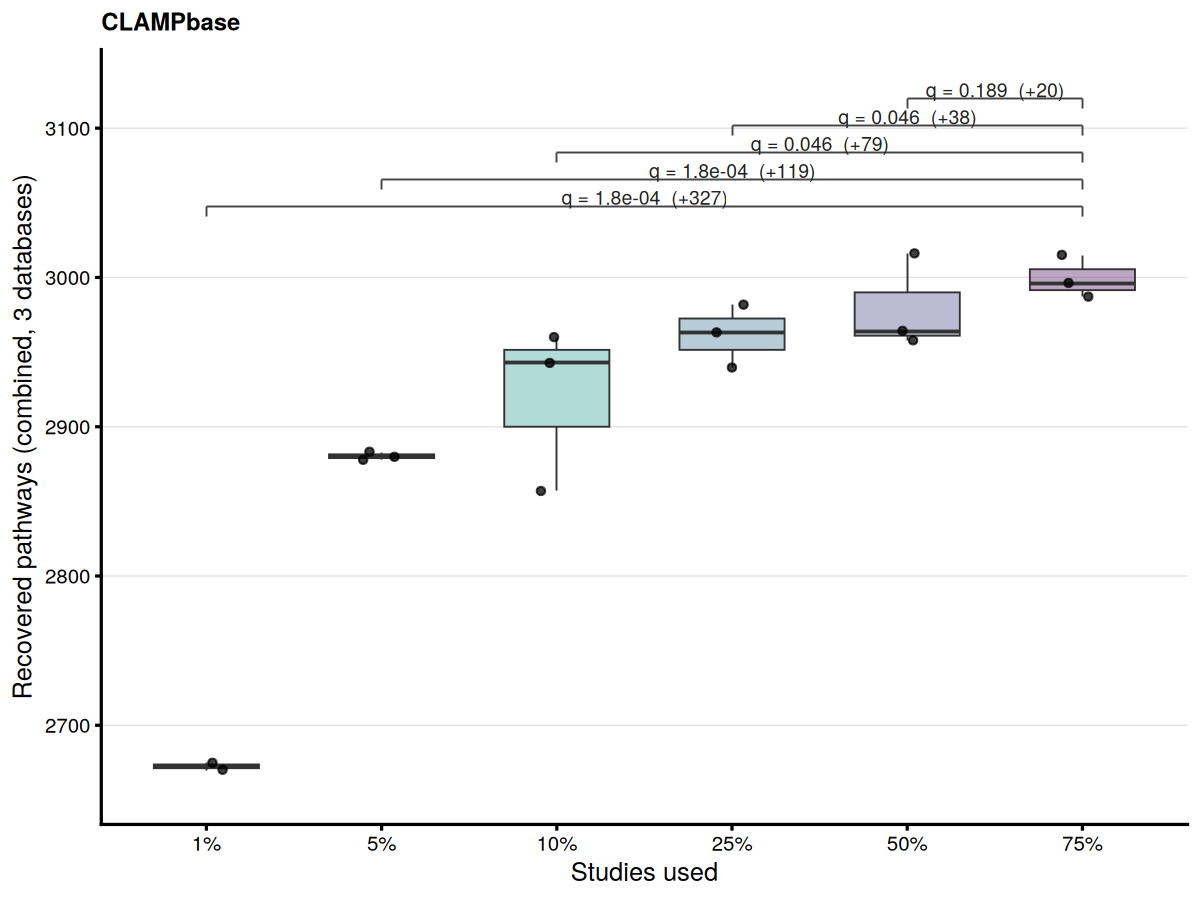

In [5]:
LAST_K <- max(sat_seed$k)
REF <- tail(levels(sat_seed$fraction_label), 1L)   # "75%"

stars_for <- function(p) {
    ifelse(is.na(p), "n/a",
    ifelse(p < 0.001, "***",
    ifelse(p < 0.01, "**",
    ifelse(p < 0.05, "*", "ns"))))
}

# Each smaller fraction against the reference, at the largest K only.
# Student's one-sided t-test (pooled variance, alternative "greater"): the
# question is directional -- whether the full compendium recovers MORE than a
# smaller one -- and the reverse is not a meaningful outcome.  Pooling variance
# is the liberal choice here, since the 75% replicates are much tighter than the
# smaller fractions'; Welch on the same data leaves 1% and 5% above 0.05
# two-sided.  With three seeds per group these p-values rest on that assumption
# as much as on the data, so the effect sizes carry the argument.
ref_tests <- function(d) {
    dd <- droplevels(d[k == LAST_K])
    if (!REF %in% levels(dd$fraction_label)) return(data.table())
    y <- dd[fraction_label == REF, recovered_pathways]
    others <- setdiff(levels(dd$fraction_label), REF)
    if (!length(others) || length(y) < 2L) return(data.table())
    out <- rbindlist(lapply(others, function(f) {
        x <- dd[fraction_label == f, recovered_pathways]
        # Welch needs at least two observations per group to estimate variance.
        if (length(x) < 2L) {
            return(data.table(fraction_label = f, n = length(x), n_ref = length(y),
                              delta = NA_real_, p = NA_real_))
        }
        data.table(fraction_label = f, n = length(x), n_ref = length(y),
                   delta = mean(y) - mean(x),
                   p = t.test(y, x, alternative = "greater", var.equal = TRUE)$p.value)
    }))
    out[, p_adj := p.adjust(p, method = "BH")]
    out[, stars := stars_for(p_adj)]
    out[]
}

ref_k_tests <- rbindlist(lapply(levels(sat_seed$model), function(m) {
    r <- ref_tests(sat_seed[model == m])
    if (nrow(r)) r[, model := m]
    r
}), fill = TRUE)

make_ref_plot <- function(model_name) {
    d <- droplevels(sat_seed[model == model_name & k == LAST_K])
    st <- ref_k_tests[model == model_name]
    if (!nrow(d) || !nrow(st)) {
        message(sprintf("%s: not enough cells at K=%d to compare against %s yet.",
                        model_name, LAST_K, REF))
        return(invisible(NULL))
    }
    lv <- levels(d$fraction_label)
    span <- range(d$recovered_pathways)
    yr <- diff(span)
    st <- copy(st)[!is.na(delta)][order(match(fraction_label, lv))]
    st[, `:=`(x = match(as.character(fraction_label), lv), xend = match(REF, lv))]
    st[, y := span[2] + yr * (0.04 + 0.052 * seq_len(.N))]
    # Label with the BH-adjusted p itself rather than significance stars, so the
    # reader sees how close a comparison actually is to the threshold.
    fmt_p <- function(p) ifelse(p < 0.001, sprintf("%.1e", p), sprintf("%.3f", p))
    st[, label := sprintf("q = %s  (%+.0f)", fmt_p(p_adj), delta)]

    ggplot(d, aes(fraction_label, recovered_pathways, fill = fraction_label)) +
        geom_boxplot(width = 0.6, outlier.shape = NA, alpha = 0.35, linewidth = 0.4,
                     show.legend = FALSE) +
        geom_jitter(width = 0.12, size = 1.6, alpha = 0.75, show.legend = FALSE) +
        geom_segment(data = st, aes(x = x, xend = xend, y = y, yend = y),
                     inherit.aes = FALSE, colour = "#444444", linewidth = 0.4) +
        geom_segment(data = st, aes(x = x, xend = x, y = y, yend = y - yr * 0.02),
                     inherit.aes = FALSE, colour = "#444444", linewidth = 0.4) +
        geom_segment(data = st, aes(x = xend, xend = xend, y = y, yend = y - yr * 0.02),
                     inherit.aes = FALSE, colour = "#444444", linewidth = 0.4) +
        geom_text(data = st, aes(x = (x + xend) / 2, y = y + yr * 0.016, label = label),
                  inherit.aes = FALSE, size = 4, colour = "#222222") +
        scale_fill_viridis_d(end = 0.9, direction = -1) +
        scale_y_continuous(expand = expansion(mult = c(0.08, 0.06))) +
        labs(x = "Studies used", y = "Recovered pathways (combined, 3 databases)",
             title = model_name) +
        theme_classic(base_size = 15) +
        theme(panel.grid.major.y = element_line(colour = "#E3E3E3", linewidth = 0.3),
              plot.title = element_text(face = "bold", size = 14))
}

options(repr.plot.width = 10, repr.plot.height = 7.5)
make_ref_plot("CLAMPfull")
make_ref_plot("CLAMPbase")


In [6]:
ref_k_tests[, .(model, comparison = sprintf("%s vs %s", REF, fraction_label),
                n_ref, n, delta = round(delta, 1), p = signif(p, 3),
                p_adj = signif(p_adj, 3), stars)][order(model)]


model,comparison,n_ref,n,delta,p,p_adj,stars
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
CLAMPbase,75% vs 1%,3,2,326.8,3.98e-05,0.000178,***
CLAMPbase,75% vs 5%,3,3,119.0,7.14e-05,0.000178,***
CLAMPbase,75% vs 10%,3,3,79.3,3.68e-02,0.046000,*
CLAMPbase,75% vs 25%,3,3,37.7,3.11e-02,0.046000,*
CLAMPbase,75% vs 50%,3,3,20.0,1.89e-01,0.189000,ns
